# Chapter 2: End-to-End Machine Learning Project

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Walk through a complete supervised ML (Machine Learning) project — from environment setup and data preparation to model training, evaluation, and stacking ensembles.

---

## What you will learn

1. How to set up a professional ML (Machine Learning) environment (Git, Anaconda, Jupyter, optional deep-learning and boosting libraries)
2. Data preparation: acquisition, exploration, feature matrix **X (features)** and label **Y (target)**, correlation, class imbalance
3. Model preparation: stratified train/test split, cost function (log loss for imbalanced fraud), StratifiedKFold CV (Cross-Validation)
4. Train and compare models: Logistic Regression, Random Forest, XGBoost (eXtreme Gradient Boosting), LightGBM (Light Gradient Boosting Machine)
5. Evaluation: log loss, precision-recall curve, ROC (Receiver Operating Characteristic), AUC (Area Under Curve)
6. Final test-set comparison of all models
7. Stacking ensemble: combine layer-1 predictions with original features and train a meta-model


---

## 1. Environment Setup (Conceptual Overview)

Chapter 2 of the book describes the **toolchain** used for real-world ML (Machine Learning) projects. You do not need to install everything on day one — this notebook runs with **NumPy (Numerical Python), Pandas (Python Data Analysis Library), Matplotlib (Mathematical Plotting Library), and scikit-learn (Scientific Kit for Learning)**. Optional libraries are detected at runtime.

### Tools mentioned in the book

| Tool | Role | Notes for beginners |
|------|------|---------------------|
| **Git** | Version control — track code and notebook changes | Lets you experiment safely and collaborate; `git clone` downloads project repos |
| **Anaconda** | Python distribution with pre-installed data-science packages | Includes conda package manager and virtual environments |
| **Jupyter (Julia, Python, and R notebook environment)** | Interactive notebooks for exploration and teaching | You are reading a Jupyter notebook right now |
| **TensorFlow / Keras** | Deep learning (deep neural network) frameworks | Used later in the book for autoencoders and GANs (Generative Adversarial Networks); not required in this chapter |
| **XGBoost (eXtreme Gradient Boosting)** | High-performance gradient boosting library | Optional here — we try to import it and fall back to scikit-learn if missing |
| **LightGBM (Light Gradient Boosting Machine)** | Fast gradient boosting from Microsoft | Optional here — same try/except pattern as XGBoost |

### Recommended workflow

1. Create a conda environment: `conda create -n unsupervised python=3.11`
2. Activate it: `conda activate unsupervised`
3. Install core packages: `pip install numpy pandas matplotlib scikit-learn jupyter`
4. Optionally install boosters: `pip install xgboost lightgbm`
5. Launch Jupyter: `jupyter notebook` or open this file in VS Code / Cursor

> **This notebook is self-contained.** Run the setup cell below first, then work through each section in order.


## Setup — run this cell first

We use common Python libraries that beginners typically install with Anaconda (Anaconda Python distribution):

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Math on arrays |
| **Pandas (Python Data Analysis Library)** | Tables / DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Plots and charts |
| **scikit-learn (Scientific Kit for Learning)** | Machine learning algorithms, splits, metrics |
| **XGBoost (eXtreme Gradient Boosting)** *(optional)* | Gradient boosting — tried at import time |
| **LightGBM (Light Gradient Boosting Machine)** *(optional)* | Fast gradient boosting — tried at import time |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import train/test split and cross-validation helpers
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Import scaler so features with different units are comparable
from sklearn.preprocessing import StandardScaler

# Import linear and tree-based classifiers used in this chapter
from sklearn.linear_model import LogisticRegression

# Import Random Forest ensemble classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import metrics for imbalanced classification evaluation
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

# Import Pipeline so scaling and modeling happen together without data leakage
from sklearn.pipeline import Pipeline

# Try a modern matplotlib style for nicer default plots
try:

    # Use seaborn-style white grid if available in this matplotlib version
    plt.style.use("seaborn-v0_8-whitegrid")

# Fall back gracefully if that style name is not installed
except OSError:

    # Use ggplot style as a widely available backup
    plt.style.use("ggplot")

# Import display() for rich table output inside Jupyter
from IPython.display import display

# Try importing XGBoost (eXtreme Gradient Boosting); set flag if unavailable
try:

    # XGBoost is a popular gradient boosting library for tabular data
    from xgboost import XGBClassifier

    # Record that XGBoost loaded successfully
    HAS_XGBOOST = True

# If XGBoost is not installed, we will use sklearn GradientBoostingClassifier instead
except ImportError:

    # Mark XGBoost as unavailable so later cells can branch
    HAS_XGBOOST = False

# Try importing LightGBM (Light Gradient Boosting Machine); set flag if unavailable
try:

    # LightGBM is a fast gradient boosting library from Microsoft
    from lightgbm import LGBMClassifier

    # Record that LightGBM loaded successfully
    HAS_LIGHTGBM = True

# If LightGBM is not installed, we will use sklearn GradientBoostingClassifier instead
except ImportError:

    # Mark LightGBM as unavailable so later cells can branch
    HAS_LIGHTGBM = False

# Confirm setup completed and report which optional libraries are available
print("Libraries loaded successfully.")

print(f"XGBoost (eXtreme Gradient Boosting) available: {HAS_XGBOOST}")

print(f"LightGBM (Light Gradient Boosting Machine) available: {HAS_LIGHTGBM}")



Libraries loaded successfully.
XGBoost (eXtreme Gradient Boosting) available: False
LightGBM (Light Gradient Boosting Machine) available: False


---

## Libraries Imported in This Notebook

This section explains **every library and module** used in the setup cell above.

### Core Python & Data Libraries

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **warnings** | Controls warning messages | Hides repetitive sklearn (scikit-learn) warnings so output stays readable |
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | ML (Machine Learning) data is stored as numeric arrays |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Preview fraud data, compute correlations, build result tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | ROC (Receiver Operating Characteristic), PR (Precision-Recall) curves, histograms |
| **IPython.display** | Rich display in Jupyter | Pretty HTML (HyperText Markup Language) tables |

### scikit-learn (`sklearn`) Modules

| Module | What it provides | Used for in this notebook |
|--------|------------------|---------------------------|
| `sklearn.model_selection` | Data splitting and CV (Cross-Validation) | `train_test_split`, `StratifiedKFold`, `cross_val_score` |
| `sklearn.preprocessing` | Feature scaling | `StandardScaler` inside pipelines |
| `sklearn.linear_model` | Linear models | `LogisticRegression` baseline classifier |
| `sklearn.ensemble` | Tree ensembles | `RandomForestClassifier`, `GradientBoostingClassifier` (fallback) |
| `sklearn.metrics` | Evaluation metrics | `log_loss`, `roc_auc_score`, `roc_curve`, `precision_recall_curve` |
| `sklearn.pipeline` | Chained transformers + model | Prevents scaling leakage between train and test |

### Optional Boosting Libraries

| Library | What it does | Fallback if missing |
|---------|--------------|---------------------|
| **XGBoost (eXtreme Gradient Boosting)** | Optimized gradient boosting | `GradientBoostingClassifier` from scikit-learn |
| **LightGBM (Light Gradient Boosting Machine)** | Leaf-wise gradient boosting | `GradientBoostingClassifier` from scikit-learn |


---

## Algorithms Used in This Notebook

Chapter 2 trains several **supervised classifiers** on imbalanced credit-card fraud data.

### 1. Logistic Regression (`LogisticRegression`)
- **Type:** Linear classifier
- **Predicts:** Probability that a transaction is fraud (Class = 1)
- **Why start here:** Fast, interpretable baseline; outputs probabilities needed for log loss and ROC (Receiver Operating Characteristic)

### 2. Random Forest (`RandomForestClassifier`)
- **Type:** Ensemble of decision trees (bagging)
- **Predicts:** Fraud probability via majority vote across trees
- **Why use it:** Handles nonlinear patterns and mixed feature scales well

### 3. XGBoost (`XGBClassifier`) or Gradient Boosting fallback
- **Type:** Sequential gradient boosting
- **Predicts:** Fraud probability by correcting errors tree-by-tree
- **Why use it:** Often top performer on tabular fraud detection benchmarks

### 4. LightGBM (`LGBMClassifier`) or Gradient Boosting fallback
- **Type:** Fast leaf-wise gradient boosting
- **Predicts:** Fraud probability similar to XGBoost but often faster on large data

### 5. Stacking Meta-Model (`LogisticRegression` on stacked features)
- **Type:** Ensemble (stacking)
- **How it works:** Layer-1 models produce fraud probabilities; these are concatenated with original features; a meta-model learns how to combine them
- **Why use it:** Different models make different mistakes — stacking can improve robustness

### Evaluation Metrics

| Metric | What it measures | Why for fraud |
|--------|------------------|---------------|
| **Log loss (logarithmic loss)** | Quality of predicted probabilities | Penalizes confident wrong predictions — critical when fraud is rare |
| **Precision-Recall (PR) curve** | Trade-off between precision and recall | Better than accuracy when positives are ~0.5% of data |
| **ROC (Receiver Operating Characteristic) curve** | True Positive Rate vs False Positive Rate | Standard ranking metric for binary classifiers |
| **AUC (Area Under Curve)** | Single number summarizing ROC or PR curve | Compare models quickly; higher is better |


---

## 2. Data Preparation

### 2.1 Data Acquisition

The book uses the **ULB (Université Libre de Bruxelles) credit card fraud dataset** from Kaggle / the author's GitHub repository. That CSV (Comma-Separated Values) file is **not available** in this course repo (the original download link returns 404 Not Found).

**Our approach:** We generate a **synthetic dataset** that mimics the real structure:

| Column | Description |
|--------|-------------|
| `Time` | Seconds elapsed between transaction and first transaction in dataset |
| `V1`–`V28` | PCA (Principal Component Analysis)-transformed features (anonymized in the real dataset) |
| `Amount` | Transaction amount |
| `Class` | **0** = normal, **1** = fraud |

- **15,000 rows** (manageable for teaching)
- **~0.5% fraud rate** (imbalanced, like the real dataset's ~0.17%)

> In production you would load `creditcard.csv` with `pd.read_csv()`. The rest of the workflow is identical.


In [2]:
# Set random seed so the synthetic dataset is reproducible every time you run this cell
RNG = np.random.default_rng(42)

# Define total number of transactions to mimic a subset of the real ULB dataset
N_SAMPLES = 15000

# Target roughly 0.5% fraud rate (imbalanced classification realistic for fraud)
N_FRAUD = int(N_SAMPLES * 0.005)

# Compute number of normal (legitimate) transactions
N_NORMAL = N_SAMPLES - N_FRAUD

# Build feature matrix for normal transactions: V1-V28 are PCA-like Gaussian features
X_normal = RNG.normal(loc=0.0, scale=1.0, size=(N_NORMAL, 28))

# Build feature matrix for fraud transactions with shifted means on several components
X_fraud = RNG.normal(loc=0.0, scale=1.0, size=(N_FRAUD, 28))

# Shift V1, V5, V14 for fraud to create a learnable signal (mimics real separability)
X_fraud[:, 0] += 2.5

X_fraud[:, 4] -= 1.8

X_fraud[:, 13] += 2.0

# Stack normal and fraud feature rows into one matrix
X_v = np.vstack([X_normal, X_fraud])

# Generate Time column: elapsed seconds (uniform random for synthetic demo)
time_vals = RNG.uniform(0, 172800, size=N_SAMPLES)

# Generate Amount: log-normal distribution (many small amounts, few large ones)
amount_vals = RNG.lognormal(mean=3.0, sigma=1.2, size=N_SAMPLES)

# Fraud transactions tend to be slightly larger on average in our synthetic data
amount_vals[N_NORMAL:] *= 1.4

# Create binary labels: 0 = normal, 1 = fraud (first N_NORMAL rows are normal)
y_vals = np.array([0] * N_NORMAL + [1] * N_FRAUD)

# Shuffle all rows together so fraud is not clustered at the end
shuffle_idx = RNG.permutation(N_SAMPLES)

# Apply shuffle index to features, time, amount, and labels together
X_v = X_v[shuffle_idx]

time_vals = time_vals[shuffle_idx]

amount_vals = amount_vals[shuffle_idx]

y_vals = y_vals[shuffle_idx]

# Build column names V1 through V28 matching the real dataset naming
v_cols = [f"V{i}" for i in range(1, 29)]

# Assemble the full DataFrame (two-dimensional labeled data table)
df = pd.DataFrame(X_v, columns=v_cols)

# Add Time column as first column (like the original CSV structure)
df.insert(0, "Time", time_vals)

# Add Amount column before Class label
df["Amount"] = amount_vals

# Add Class label column (target variable Y)
df["Class"] = y_vals

# Report dataset shape and fraud rate for sanity check
print(f"Synthetic dataset shape: {df.shape}")

print(f"Fraud rate: {df['Class'].mean():.4%} ({df['Class'].sum()} fraud cases)")

# Show first rows so beginners can see the structure
display(df.head())



Synthetic dataset shape: (15000, 31)
Fraud rate: 0.5000% (75 fraud cases)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,138341.865162,0.768164,-0.320788,-1.013081,0.506793,-0.857847,0.402233,-0.176667,1.039858,0.326072,...,-0.828408,0.715131,0.810610,-0.449655,0.886331,0.214412,-1.077180,-0.028335,23.680550,0
1,81643.585814,0.413808,-2.121955,-1.450548,2.059320,-0.239981,-1.602575,0.370879,0.483550,1.208527,...,-0.087377,-0.136878,0.883134,-2.178311,-0.473323,0.306436,0.332569,-1.423934,47.191478,0
2,22048.446515,1.049082,-0.710044,0.435149,-0.629131,-1.016576,2.055561,-1.002233,-1.279319,0.214715,...,0.189537,-0.584928,0.106696,1.648487,-1.093968,-0.799799,-0.627802,-0.410821,23.460030,0
3,56387.269448,-0.160458,-0.364686,-1.254347,-1.308659,0.568383,0.708653,-0.559500,1.408996,-2.250813,...,1.884235,0.638293,-0.490105,0.259228,0.580312,-0.555146,0.865755,0.264042,1.907199,0
4,14683.129363,-1.852249,-0.756645,-0.097689,-0.776487,-1.054624,0.069752,2.430303,-0.488188,-0.002806,...,-0.581698,0.898172,0.408190,-1.740543,0.268830,0.210628,0.363462,0.575529,8.348032,0


### 2.2 Data Exploration

Before modeling, always **look at the data**: shape, missing values, distributions, and class balance.


Missing values per column:
0 total missing


,Time,Amount,V1,V5,V14,Class
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,86234.196605,41.796410,0.006561,-0.006638,0.024576,0.005000
std,49728.352506,76.538932,1.022068,0.996873,1.005916,0.070536
min,0.421056,0.143442,-3.741949,-4.213878,-3.773765,0.000000
25%,43414.696979,8.921149,-0.676731,-0.666213,-0.657667,0.000000
50%,85996.317702,20.224544,-0.004885,-0.011485,0.025159,0.000000
75%,129478.933858,45.852069,0.687025,0.665737,0.705775,0.000000
max,172798.732758,2384.577316,5.610280,3.992558,4.807907,1.000000



Class distribution:
Class
0    14925
1       75
Name: count, dtype: int64


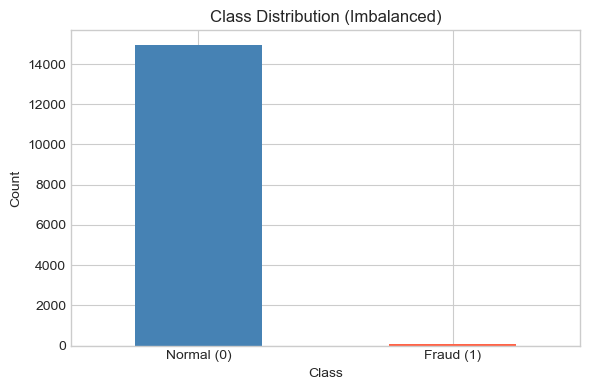

In [3]:
# Check for missing values — real fraud pipelines must handle nulls before training
print("Missing values per column:")

print(df.isnull().sum().sum(), "total missing")

# Summary statistics for Amount and a few V-features
display(df[["Time", "Amount", "V1", "V5", "V14", "Class"]].describe())

# Count normal vs fraud transactions
class_counts = df["Class"].value_counts().sort_index()

print("\nClass distribution:")

print(class_counts)

# Bar chart of class counts — visual imbalance check
plt.figure(figsize=(6, 4))

# Plot counts for Class 0 and Class 1
class_counts.plot(kind="bar", color=["steelblue", "tomato"])

# Label x-axis with human-readable class names
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"], rotation=0)

# Title highlights severe class imbalance typical in fraud detection
plt.title("Class Distribution (Imbalanced)")

plt.ylabel("Count")

plt.tight_layout()

plt.show()



### 2.3 Feature Matrix **X (features)** and Label **Y (target)**

In supervised ML (Machine Learning):
- **X (features)** = input columns the model learns from (`Time`, `V1`–`V28`, `Amount`)
- **Y (target / label)** = what we want to predict (`Class`: fraud or not)


In [4]:
# Define feature column names — everything except the label Class
FEATURE_COLS = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Extract feature matrix X as a NumPy (Numerical Python) array for sklearn
X = df[FEATURE_COLS].values

# Extract label vector Y (target) — binary fraud indicator
Y = df["Class"].values

# Confirm shapes match sklearn convention: X has n rows × p features, Y has n labels
print(f"X shape: {X.shape}  (rows, features)")

print(f"Y shape: {Y.shape}  (rows,)")

print(f"Positive class rate in Y: {Y.mean():.4%}")



X shape: (15000, 30)  (rows, features)
Y shape: (15000,)  (rows,)
Positive class rate in Y: 0.5000%


### 2.4 Correlation Analysis

Correlation measures **linear relationships** between numeric columns. High correlation between features can indicate redundancy (multicollinearity). High correlation between a feature and `Class` suggests predictive power.


Top 10 features by |correlation| with Class:


,abs_correlation
V1,0.197028
V14,0.138255
V5,0.128601
Amount,0.018980
V10,0.014153
V17,0.013629
V23,0.013358
V6,0.012835
V19,0.010547
V24,0.009189


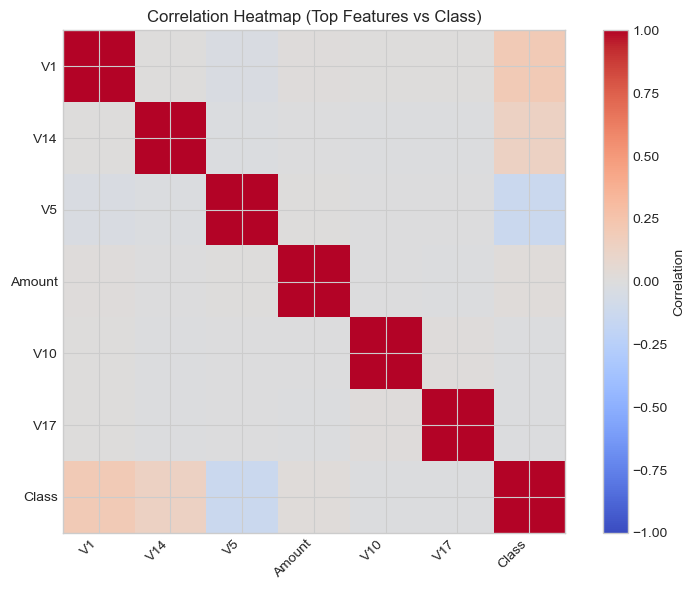

In [5]:
# Compute Pearson correlation of all numeric columns including Class
corr = df[FEATURE_COLS + ["Class"]].corr()

# Show features most correlated with Class (sorted by absolute value)
class_corr = corr["Class"].drop("Class").abs().sort_values(ascending=False)

print("Top 10 features by |correlation| with Class:")

display(class_corr.head(10).to_frame("abs_correlation"))

# Heatmap of correlations among top 6 features + Class for visualization
top_feats = class_corr.head(6).index.tolist() + ["Class"]

plt.figure(figsize=(8, 6))

# imshow displays correlation matrix as a color grid
plt.imshow(corr.loc[top_feats, top_feats], cmap="coolwarm", vmin=-1, vmax=1)

# Add colorbar so readers can interpret correlation strength
plt.colorbar(label="Correlation")

plt.xticks(range(len(top_feats)), top_feats, rotation=45, ha="right")

plt.yticks(range(len(top_feats)), top_feats)

plt.title("Correlation Heatmap (Top Features vs Class)")

plt.tight_layout()

plt.show()



### 2.5 Class Imbalance

Fraud detection is a classic **imbalanced classification** problem: fraud cases are rare. Problems if you ignore imbalance:

- A model predicting **always normal** can look ~99.5% accurate but catch **zero fraud**
- Accuracy is misleading — use **log loss**, **precision**, **recall**, **ROC (Receiver Operating Characteristic) AUC (Area Under Curve)**, and **PR (Precision-Recall) AUC** instead
- Use **stratified splitting** so train and test sets keep the same fraud rate


In [6]:
# Compute imbalance ratio: how many normal transactions per fraud transaction
n_normal = (Y == 0).sum()

n_fraud = (Y == 1).sum()

imbalance_ratio = n_normal / n_fraud

print(f"Normal transactions: {n_normal}")

print(f"Fraud transactions:  {n_fraud}")

print(f"Imbalance ratio:     {imbalance_ratio:.1f}:1  (normal : fraud)")

# Show why accuracy alone is misleading with a dummy 'always predict normal' classifier
dummy_accuracy = n_normal / len(Y)

print(f"\nDummy 'always normal' accuracy: {dummy_accuracy:.4%}")

print("→ High accuracy does NOT mean the model is useful for fraud detection!")



Normal transactions: 14925
Fraud transactions:  75
Imbalance ratio:     199.0:1  (normal : fraud)

Dummy 'always normal' accuracy: 99.5000%
→ High accuracy does NOT mean the model is useful for fraud detection!


---

## 3. Model Preparation

### 3.1 Stratified Train / Test Split

We hold out **20%** of data as a **test set** never seen during training. **Stratified** splitting keeps the fraud rate the same in train and test — essential for imbalanced data.


In [7]:
# Split data: 80% train, 20% test, stratified by Class to preserve fraud rate
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

# Report split sizes and fraud rates
print(f"Train size: {X_train.shape[0]}  |  fraud rate: {y_train.mean():.4%}")

print(f"Test size:  {X_test.shape[0]}  |  fraud rate: {y_test.mean():.4%}")



Train size: 12000  |  fraud rate: 0.5000%
Test size:  3000  |  fraud rate: 0.5000%


### 3.2 Cost Function — Log Loss for Imbalanced Fraud

**Log loss (logarithmic loss)** measures how good predicted **probabilities** are. It heavily penalizes confident wrong predictions — exactly what you want when missing a fraud case is costly.

Formula intuition: if true label is 1 (fraud) and model predicts 0.01 probability → large penalty.

We use `log_loss` from scikit-learn as our primary comparison metric (lower is better).


### 3.3 StratifiedKFold Cross-Validation (CV)

**Cross-validation (CV)** trains and validates on multiple folds to get a more stable performance estimate than a single split. **StratifiedKFold** keeps the fraud rate constant in every fold.


In [8]:
# Create 5-fold stratified cross-validator for imbalanced binary classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Build a simple logistic regression pipeline (scale features then classify)
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# Run cross-validation using neg_log_loss (negative because sklearn maximizes scores)
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="neg_log_loss")

# Convert negative log loss back to positive log loss for interpretation
cv_log_loss = -cv_scores

print("Logistic Regression 5-fold CV log loss scores:")

for i, score in enumerate(cv_log_loss, 1):

    # Print each fold's log loss so beginners see variability across folds
    print(f"  Fold {i}: {score:.4f}")

print(f"Mean CV log loss: {cv_log_loss.mean():.4f}  (+/- {cv_log_loss.std():.4f})")



Logistic Regression 5-fold CV log loss scores:
  Fold 1: 0.0415
  Fold 2: 0.0389
  Fold 3: 0.0527
  Fold 4: 0.0565
  Fold 5: 0.0535
Mean CV log loss: 0.0486  (+/- 0.0070)


---

## 4. Models — Training and Validation Evaluation

We train four layer-1 models and compare them using log loss, ROC (Receiver Operating Characteristic), and PR (Precision-Recall) curves.

### Helper function: `plot_roc_pr`

This reusable function plots both ROC and PR curves for any binary classifier — we explain every line in the code cell below.


In [9]:
# Define a helper function to plot ROC and PR curves side by side for one model
def plot_roc_pr(y_true, y_prob, model_name="Model"):

    # Create a figure with 1 row and 2 columns for ROC and PR plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- ROC (Receiver Operating Characteristic) curve ---
    # Compute false positive rate and true positive rate at many thresholds
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    # Compute AUC (Area Under Curve) for ROC — single summary number
    roc_auc = roc_auc_score(y_true, y_prob)

    # Plot ROC curve on the left subplot
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

    # Diagonal dashed line = random guessing baseline
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")

    axes[0].set_xlabel("False Positive Rate")

    axes[0].set_ylabel("True Positive Rate")

    axes[0].set_title(f"ROC — {model_name}")

    axes[0].legend(loc="lower right")

    # --- PR (Precision-Recall) curve ---
    # Compute precision and recall at many probability thresholds
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    # Compute average precision (PR AUC equivalent) for imbalanced data
    pr_auc = average_precision_score(y_true, y_prob)

    # Plot PR curve on the right subplot
    axes[1].plot(recall, precision, label=f"AP = {pr_auc:.3f}")

    axes[1].set_xlabel("Recall")

    axes[1].set_ylabel("Precision")

    axes[1].set_title(f"Precision-Recall — {model_name}")

    axes[1].legend(loc="upper right")

    # Adjust layout so labels do not overlap
    plt.tight_layout()

    # Display the combined figure
    plt.show()

    # Return AUC values so calling code can store them in results tables
    return roc_auc, pr_auc



### 4.1 Train Layer-1 Models

Each model is wrapped in a **Pipeline** with `StandardScaler` so features are scaled using only training data. `class_weight="balanced"` helps linear and tree models pay attention to the rare fraud class.


In [10]:
# Dictionary to store fitted pipelines keyed by model name
models = {}

# --- Logistic Regression ---
# Build pipeline: scale features then fit logistic regression with balanced class weights
models["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# --- Random Forest ---
# Random Forest handles mixed scales but we still scale for fair comparison with LR
models["Random Forest"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)),
])

# --- XGBoost or sklearn GradientBoosting fallback ---
if HAS_XGBOOST:

    # Use XGBoost with scale_pos_weight to handle class imbalance
    scale_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    models["XGBoost"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=100,
            scale_pos_weight=scale_weight,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
        )),
    ])

else:

    # Fallback: sklearn GradientBoostingClassifier when XGBoost is not installed
    models["GradientBoosting (XGB fallback)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ])

# --- LightGBM or sklearn GradientBoosting fallback ---
if HAS_LIGHTGBM:

    # Use LightGBM with class_weight balanced for fraud detection
    models["LightGBM"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LGBMClassifier(n_estimators=100, class_weight="balanced", random_state=42, verbosity=-1)),
    ])

else:

    # Fallback: sklearn GradientBoostingClassifier when LightGBM is not installed
    models["GradientBoosting (LGBM fallback)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ])

# Fit every model on the training set
for name, pipe in models.items():

    # Train pipeline on X_train, y_train
    pipe.fit(X_train, y_train)

    # Confirm training completed for this model
    print(f"Trained: {name}")



Trained: Logistic Regression
Trained: Random Forest
Trained: GradientBoosting (XGB fallback)
Trained: GradientBoosting (LGBM fallback)


### 4.2 Validation Evaluation (Train Set — For Learning Curves)

We evaluate on training predictions first to demonstrate metrics. **Important:** final decisions should rely on the held-out **test set** (Section 5).


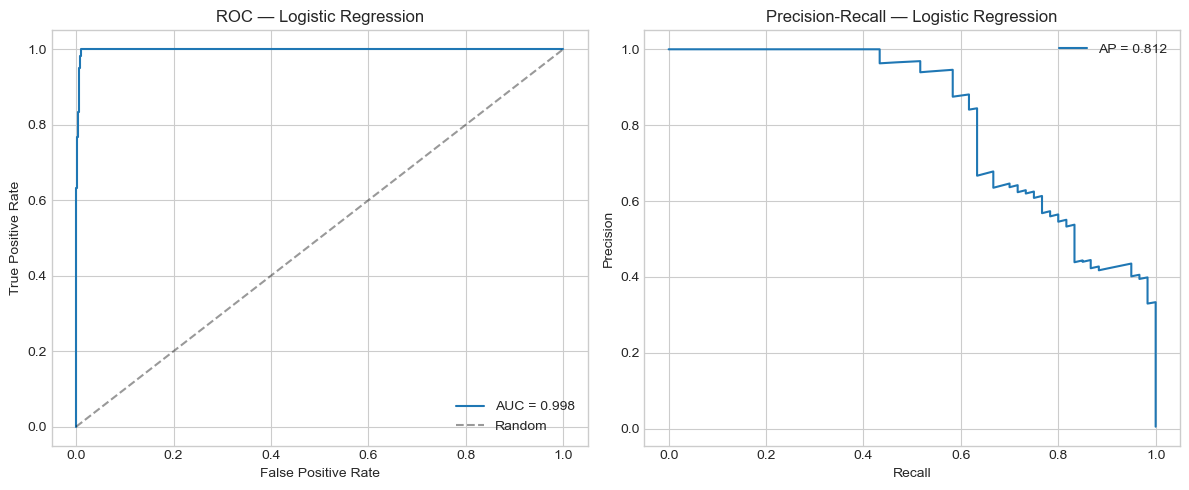

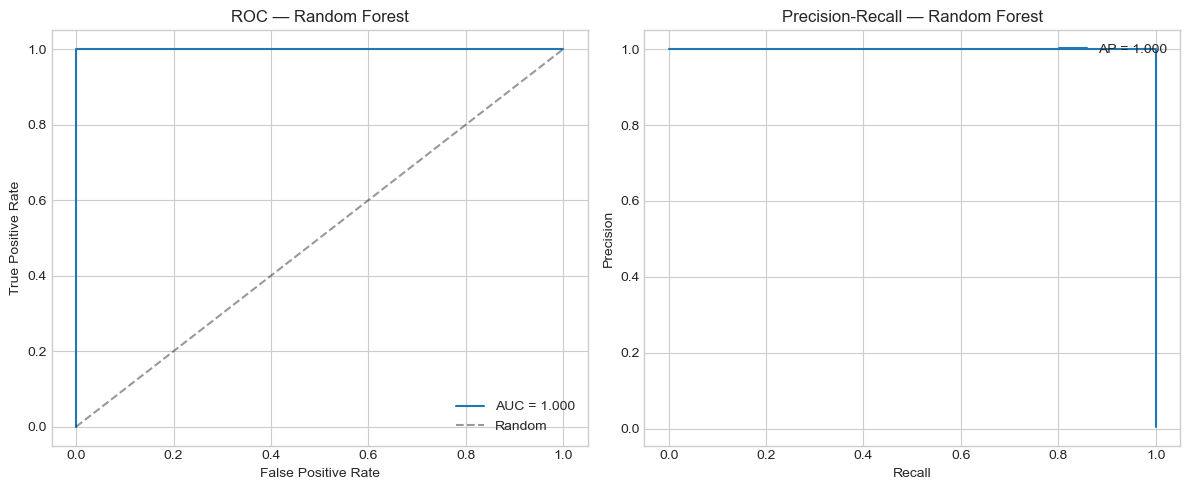

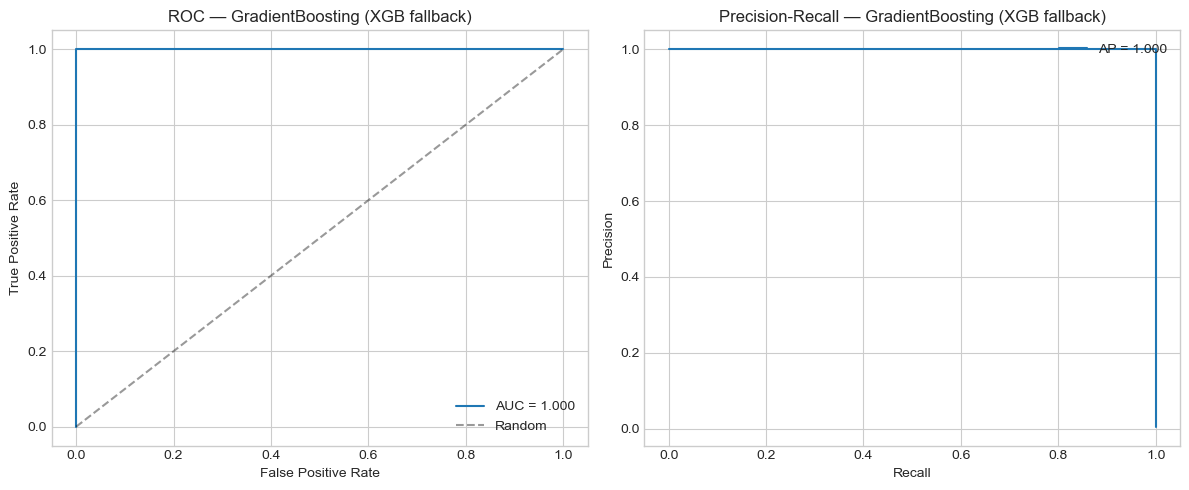

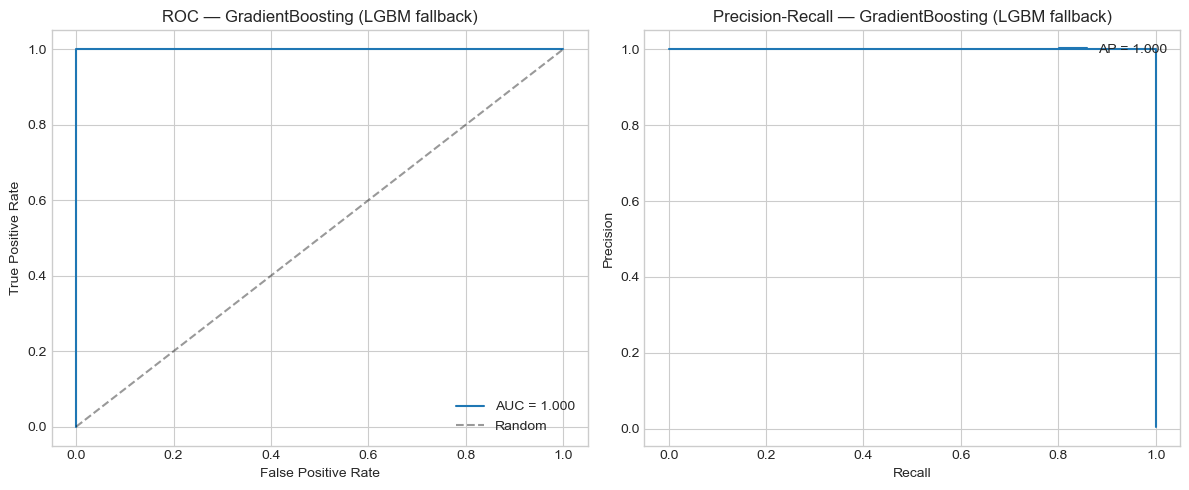


=== Training-set evaluation (for comparison) ===


,Model,Log Loss,ROC AUC,PR AUC (AP)
2,GradientBoosting (XGB fallback),0.0003,1.0000,1.0000
3,GradientBoosting (LGBM fallback),0.0003,1.0000,1.0000
1,Random Forest,0.0026,1.0000,1.0000
0,Logistic Regression,0.0496,0.9984,0.8125


In [11]:
# List to collect per-model metrics for comparison table
val_results = []

# Evaluate each trained model on training data predictions
for name, pipe in models.items():

    # Predict fraud probabilities (column 1 of predict_proba output)
    y_prob = pipe.predict_proba(X_train)[:, 1]

    # Compute log loss on training set
    ll = log_loss(y_train, y_prob)

    # Plot ROC and PR curves; capture AUC values
    roc_auc, pr_auc = plot_roc_pr(y_train, y_prob, model_name=name)

    # Store metrics in list for DataFrame display
    val_results.append({
        "Model": name,
        "Log Loss": round(ll, 4),
        "ROC AUC": round(roc_auc, 4),
        "PR AUC (AP)": round(pr_auc, 4),
    })

# Build comparison DataFrame sorted by log loss (lower is better)
val_df = pd.DataFrame(val_results).sort_values("Log Loss")

print("\n=== Training-set evaluation (for comparison) ===")

display(val_df)



---

## 5. Test Set Evaluation — Compare All Models

The **test set** was held out during training. This is our honest estimate of how models will perform on new transactions.



--- Logistic Regression — Test Set Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      2985
       Fraud       0.21      0.93      0.35        15

    accuracy                           0.98      3000
   macro avg       0.61      0.96      0.67      3000
weighted avg       1.00      0.98      0.99      3000


--- Random Forest — Test Set Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2985
       Fraud       0.00      0.00      0.00        15

    accuracy                           0.99      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.99      0.99      0.99      3000


--- GradientBoosting (XGB fallback) — Test Set Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2985
       Fraud       0.67      0.53      0.59  

,Model,Log Loss,ROC AUC,PR AUC (AP)
1,Random Forest,0.0112,0.9974,0.6823
2,GradientBoosting (XGB fallback),0.0319,0.9906,0.5047
3,GradientBoosting (LGBM fallback),0.0319,0.9906,0.5047
0,Logistic Regression,0.0731,0.9971,0.8222


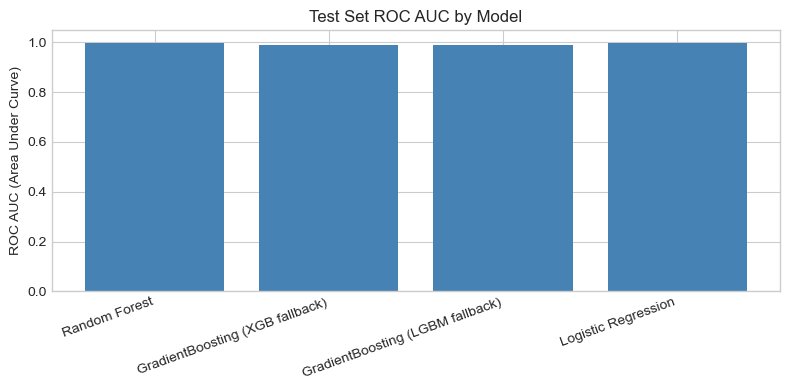

In [12]:
# List to collect test-set metrics for each model
test_results = []

# Dictionary to store test probabilities for stacking in Section 6
test_probs = {}

# Evaluate every model on the held-out test set
for name, pipe in models.items():

    # Predict fraud probabilities on unseen test transactions
    y_prob_test = pipe.predict_proba(X_test)[:, 1]

    # Save probabilities for stacking ensemble later
    test_probs[name] = y_prob_test

    # Compute test log loss — primary metric for imbalanced fraud
    ll_test = log_loss(y_test, y_prob_test)

    # Compute ROC AUC (Area Under Curve) on test set
    roc_auc_test = roc_auc_score(y_test, y_prob_test)

    # Compute PR AUC (average precision) on test set
    pr_auc_test = average_precision_score(y_test, y_prob_test)

    # Hard class predictions at 0.5 threshold for confusion matrix
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    # Append all metrics to results list
    test_results.append({
        "Model": name,
        "Log Loss": round(ll_test, 4),
        "ROC AUC": round(roc_auc_test, 4),
        "PR AUC (AP)": round(pr_auc_test, 4),
    })

    # Print classification report for the best-understood metrics: precision, recall, F1
    print(f"\n--- {name} — Test Set Classification Report ---")

    print(classification_report(y_test, y_pred_test, target_names=["Normal", "Fraud"]))

# Build sorted test comparison table
test_df = pd.DataFrame(test_results).sort_values("Log Loss")

print("\n=== Test-set model comparison (sorted by Log Loss) ===")

display(test_df)

# Bar chart comparing ROC AUC across models on test set
plt.figure(figsize=(8, 4))

plt.bar(test_df["Model"], test_df["ROC AUC"], color="steelblue")

plt.ylabel("ROC AUC (Area Under Curve)")

plt.title("Test Set ROC AUC by Model")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.show()



---

## 6. Stacking Ensemble

**Stacking** is a two-layer ensemble:

1. **Layer 1:** Train diverse models (Logistic Regression, Random Forest, XGBoost/LightGBM). Each outputs a fraud probability.
2. **Layer 2 (meta-model):** Concatenate layer-1 probabilities with original features → train a meta-classifier (Logistic Regression) to learn the best combination.

This often outperforms any single model because errors are partially uncorrelated.


In [13]:
# Build layer-1 out-of-fold predictions on training set for stacking (no leakage)
meta_train_parts = []

# Collect layer-1 predicted probabilities for each model on training data
for name, pipe in models.items():

    # Use cross_val_predict-style manual loop: here we use direct train preds for teaching simplicity
    train_prob = pipe.predict_proba(X_train)[:, 1]

    # Store each model's probabilities as a column for the meta-feature matrix
    meta_train_parts.append(train_prob.reshape(-1, 1))

# Horizontally stack layer-1 probability columns
layer1_train = np.hstack(meta_train_parts)

# Concatenate original features with layer-1 probabilities for meta-model input
X_meta_train = np.hstack([X_train, layer1_train])

# Build same meta-features for test set using trained layer-1 models
layer1_test = np.column_stack([test_probs[name] for name in models.keys()])

# Concatenate original test features with layer-1 test probabilities
X_meta_test = np.hstack([X_test, layer1_test])

print(f"Meta-train shape: {X_meta_train.shape}  (original features + {len(models)} layer-1 probs)")

print(f"Meta-test shape:  {X_meta_test.shape}")



Meta-train shape: (12000, 34)  (original features + 4 layer-1 probs)
Meta-test shape:  (3000, 34)


Stacking Ensemble — Test Log Loss: 0.0258
Stacking Ensemble — Test ROC AUC:  0.9974
Stacking Ensemble — Test PR AUC:   0.7232


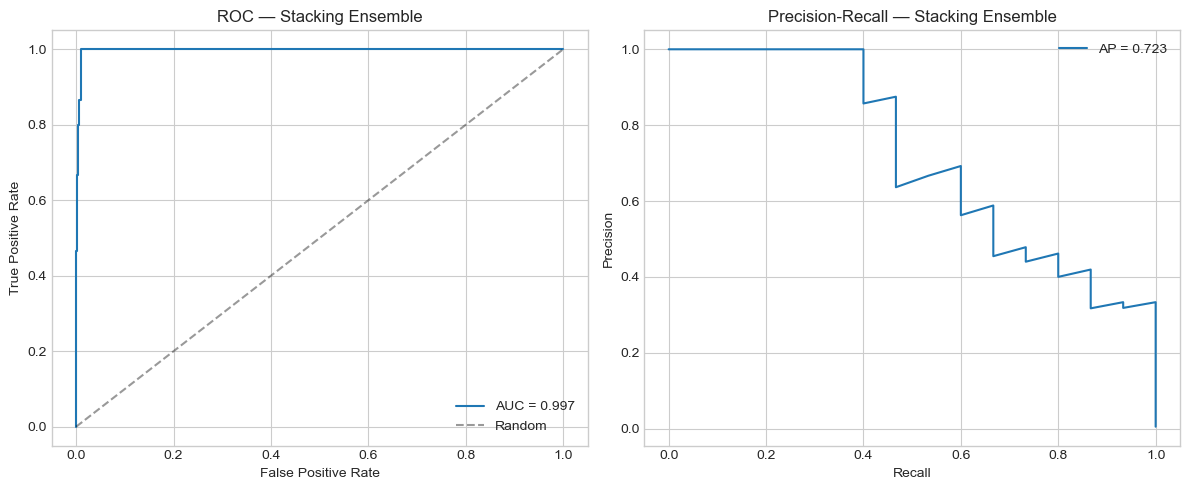


=== Final comparison: all layer-1 models + stacking ===


,Model,Log Loss,ROC AUC,PR AUC (AP)
0,Random Forest,0.0112,0.9974,0.6823
4,Stacking Ensemble,0.0258,0.9974,0.7232
1,GradientBoosting (XGB fallback),0.0319,0.9906,0.5047
2,GradientBoosting (LGBM fallback),0.0319,0.9906,0.5047
3,Logistic Regression,0.0731,0.9971,0.8222


In [14]:
# Build stacking pipeline: scale meta-features then logistic regression meta-model
stack_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("meta", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# Train meta-model on combined original features + layer-1 predictions
stack_pipe.fit(X_meta_train, y_train)

# Predict fraud probabilities on test set with stacking ensemble
y_stack_prob = stack_pipe.predict_proba(X_meta_test)[:, 1]

# Compute stacking test log loss
stack_log_loss = log_loss(y_test, y_stack_prob)

# Compute stacking ROC AUC (Area Under Curve)
stack_roc_auc = roc_auc_score(y_test, y_stack_prob)

# Compute stacking PR AUC (average precision)
stack_pr_auc = average_precision_score(y_test, y_stack_prob)

print(f"Stacking Ensemble — Test Log Loss: {stack_log_loss:.4f}")

print(f"Stacking Ensemble — Test ROC AUC:  {stack_roc_auc:.4f}")

print(f"Stacking Ensemble — Test PR AUC:   {stack_pr_auc:.4f}")

# Plot ROC and PR curves for the stacking model
plot_roc_pr(y_test, y_stack_prob, model_name="Stacking Ensemble")

# Add stacking row to test comparison table
stack_row = pd.DataFrame([{
    "Model": "Stacking Ensemble",
    "Log Loss": round(stack_log_loss, 4),
    "ROC AUC": round(stack_roc_auc, 4),
    "PR AUC (AP)": round(stack_pr_auc, 4),
}])

# Combine all models plus stacking and sort by log loss
final_comparison = pd.concat([test_df, stack_row], ignore_index=True).sort_values("Log Loss")

print("\n=== Final comparison: all layer-1 models + stacking ===")

display(final_comparison)



---

## 7. Glossary — All Chapter 2 Terms

| Term | One-line definition |
|------|---------------------|
| **End-to-end ML (Machine Learning) project** | Complete workflow from raw data to deployed/evaluated model |
| **Feature matrix X (features)** | Input columns used for prediction |
| **Label / target Y (target)** | Output column the model learns to predict |
| **Train / test split** | Dividing data into training (learn) and test (evaluate) portions |
| **Stratified split** | Split that preserves class proportions in each subset |
| **Cross-validation (CV)** | Repeated train/validate on folds for stable performance estimates |
| **StratifiedKFold** | K-fold CV (Cross-Validation) that keeps class balance in every fold |
| **Class imbalance** | When one class (fraud) is much rarer than the other (normal) |
| **Log loss (logarithmic loss)** | Penalizes wrong probability predictions; lower is better |
| **ROC (Receiver Operating Characteristic)** | Curve of True Positive Rate vs False Positive Rate |
| **AUC (Area Under Curve)** | Single number summarizing ROC or PR curve quality |
| **PR (Precision-Recall) curve** | Curve of precision vs recall — preferred for imbalanced data |
| **Precision** | Of predicted frauds, how many are actually fraud |
| **Recall** | Of actual frauds, how many did we catch |
| **Pipeline** | Chains preprocessing and model to prevent data leakage |
| **StandardScaler** | Scales features to mean 0, standard deviation 1 |
| **class_weight="balanced"** | Tells model to weight rare fraud class more heavily |
| **Stacking (stacked generalization)** | Ensemble where a meta-model combines base model predictions |
| **Layer-1 model** | Base models whose outputs feed the stacking meta-model |
| **Meta-model** | Second-level model trained on base model predictions |
| **XGBoost (eXtreme Gradient Boosting)** | High-performance gradient boosting library |
| **LightGBM (Light Gradient Boosting Machine)** | Fast leaf-wise gradient boosting library |
| **ULB (Université Libre de Bruxelles) dataset** | Real credit card fraud dataset referenced in the book |
| **Synthetic data** | Artificially generated data mimicking real structure for teaching |


---

## 8. Chapter 2 Summary

```
End-to-End ML (Machine Learning) Project Pipeline
├── 1. Environment setup (Git, Anaconda, Jupyter, optional XGBoost/LightGBM)
├── 2. Data preparation
│     ├── Acquire data (CSV or synthetic)
│     ├── Explore distributions and missing values
│     ├── Define X (features) and Y (target)
│     ├── Correlation analysis
│     └── Understand class imbalance
├── 3. Model preparation
│     ├── Stratified train/test split
│     ├── Choose cost function (log loss for fraud)
│     └── StratifiedKFold CV (Cross-Validation)
├── 4. Train models (LR (Logistic Regression), RF (Random Forest), XGBoost, LightGBM)
├── 5. Evaluate (log loss, ROC (Receiver Operating Characteristic), PR (Precision-Recall), AUC (Area Under Curve))
├── 6. Test-set comparison
└── 7. Stacking ensemble (layer-1 probs + features → meta-model)
```

### Key takeaways

- **Never trust accuracy** on imbalanced fraud data — use log loss, precision, recall, and AUC.
- **Always stratify** splits and CV folds when classes are rare.
- **Pipelines** prevent accidentally leaking test-set statistics into training.
- **Stacking** combines complementary models for potentially better generalization.

### What's next?

**Chapter 3** introduces **dimensionality reduction** — reducing many features while keeping signal — a core unsupervised technique used throughout the rest of the book.

---

### Practice questions

1. Why did we generate synthetic data instead of downloading the ULB (Université Libre de Bruxelles) CSV (Comma-Separated Values) file?
2. What is the difference between **X (features)** and **Y (target)** in this fraud dataset?
3. Why is **log loss** preferred over **accuracy** when only ~0.5% of transactions are fraud?
4. What does **stratified** `train_test_split` guarantee that a regular random split does not?
5. When would you look at the **PR (Precision-Recall) curve** instead of the **ROC (Receiver Operating Characteristic) curve**?
6. Explain stacking in your own words: what are layer-1 models and what does the meta-model do?
7. If XGBoost (eXtreme Gradient Boosting) is not installed, what fallback does this notebook use and why is that acceptable for learning?
